# Visit with Us — Wellness Tourism Package Purchase Prediction

## End-to-End MLOps Project

**Objective:** Build an automated machine-learning pipeline that predicts whether a customer will purchase a tourism package, while demonstrating data registration, preparation, experimentation tracking, model registration, Docker/Streamlit deployment, Hugging Face hosting, and GitHub Actions CI/CD.

**Primary deliverable:** This notebook is the main submission artifact. It is executed end-to-end and exported to HTML.

> **Note for final cloud deployment:** Set the Hugging Face and GitHub configuration values in the configuration cell before running the optional upload/deployment cells. The notebook can be executed locally without credentials; the deployment code is included and ready for the required public Hugging Face Space.

## 1. Business Understanding

Manual identification of likely package buyers is slow and inconsistent. A predictive model can rank customers before outreach so that sales teams focus on customers with a higher probability of purchase.

### Success criteria
- Clean and prepare the customer dataset.
- Build a reproducible preprocessing + modeling pipeline.
- Compare multiple permitted algorithms.
- Tune hyperparameters using cross-validation.
- Track tuned parameters and evaluation metrics.
- Register the best model in the Hugging Face Model Hub.
- Serve predictions through Streamlit and Docker.
- Automate the workflow with GitHub Actions.

In [1]:
# 2. Project structure and imports
import os, sys, json, joblib, shutil, warnings
from pathlib import Path
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

# The notebook lives inside the master project folder.
MASTER_DIR = Path(".")
DATA_DIR = MASTER_DIR / "data"
MODEL_DIR = MASTER_DIR / "model_building"
DEPLOY_DIR = MASTER_DIR / "deployment"
for p in [DATA_DIR, MODEL_DIR, DEPLOY_DIR, MASTER_DIR / ".github" / "workflows"]:
    p.mkdir(parents=True, exist_ok=True)

print("Master folder:", MASTER_DIR.resolve())
print("Folders verified:", [str(p) for p in [DATA_DIR, MODEL_DIR, DEPLOY_DIR]])

Master folder: /mnt/data/tourism_project
Folders verified: ['data', 'model_building', 'deployment']


## 3. Data Registration

The supplied `tourism.csv` is copied into the project's `data` folder for the initial registration step. In the CI/CD workflow, `register_dataset.py` uploads this file to the configured Hugging Face Dataset repository.

For the executed notebook, the local copy is used so that all outputs are reproducible without requiring private credentials.

In [2]:
# Copy the supplied dataset into the project data folder.
# In the submitted notebook, the dataset is already present in data/tourism.csv.
SOURCE = Path("/mnt/data/tourism.csv")
TARGET = DATA_DIR / "tourism.csv"

if SOURCE.exists() and SOURCE.resolve() != TARGET.resolve():
    shutil.copy2(SOURCE, TARGET)

if not TARGET.exists():
    raise FileNotFoundError("Please place tourism.csv inside the project's data folder.")

df_raw = pd.read_csv(TARGET)
print("Registered dataset:", TARGET.resolve())
print("Shape:", df_raw.shape)
display(df_raw.head())

Registered dataset: /mnt/data/tourism_project/data/tourism.csv
Shape: (4128, 21)


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


### Hugging Face dataset registration code

The following script is also stored as `model_building/register_dataset.py`. It creates the dataset repository if necessary and uploads `tourism.csv`.

In [3]:
# Optional: execute only after setting HF_TOKEN and HF_DATASET_REPO.
# os.environ["HF_TOKEN"] = "YOUR_TOKEN"
# os.environ["HF_DATASET_REPO"] = "YOUR_USERNAME/tourism-dataset"
# !python tourism_project/model_building/register_dataset.py

print("Registration script prepared. CI/CD will execute it automatically when HF secrets are configured.")

Registration script prepared. CI/CD will execute it automatically when HF secrets are configured.


## 4. Data Preparation

We inspect structure, duplicates, missing values, class balance and numerical/categorical distributions. `Unnamed: 0` is an export/index artifact and `CustomerID` is an identifier rather than a predictive feature, so both are removed. The target is `ProdTaken`.

The preprocessing pipeline later imputes missing values and one-hot encodes categorical variables, making the solution robust to unseen categories at prediction time.

In [4]:
# Basic inspection
print("Dataset shape:", df_raw.shape)
print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nTarget distribution:")
display(df_raw["ProdTaken"].value_counts().rename_axis("ProdTaken").to_frame("count"))
display((df_raw["ProdTaken"].value_counts(normalize=True)*100).round(2).rename_axis("ProdTaken").to_frame("percent"))

Dataset shape: (4128, 21)

Data types:


,dtype
Unnamed: 0,int64
CustomerID,int64
ProdTaken,int64
Age,float64
TypeofContact,object
CityTier,int64
DurationOfPitch,float64
Occupation,object
Gender,object
NumberOfPersonVisiting,int64



Missing values:


,missing
Unnamed: 0,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0



Duplicate rows: 0

Target distribution:


,count
ProdTaken,
0,3331
1,797


,percent
ProdTaken,
0,80.69
1,19.31


In [5]:
# Clean data
df = df_raw.drop(columns=["Unnamed: 0", "CustomerID"], errors="ignore").copy()
df = df.drop_duplicates().reset_index(drop=True)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Shape after cleaning:", df.shape)
print("Removed columns: Unnamed: 0, CustomerID")
print("Remaining duplicates:", df.duplicated().sum())
display(df.head())

Shape after cleaning: (4011, 19)
Removed columns: Unnamed: 0, CustomerID
Remaining duplicates: 0


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


### Exploratory analysis

The target is imbalanced, with non-buyers representing the majority class. Therefore, accuracy alone should not determine model selection; ROC-AUC, precision, recall and F1 are also reported.

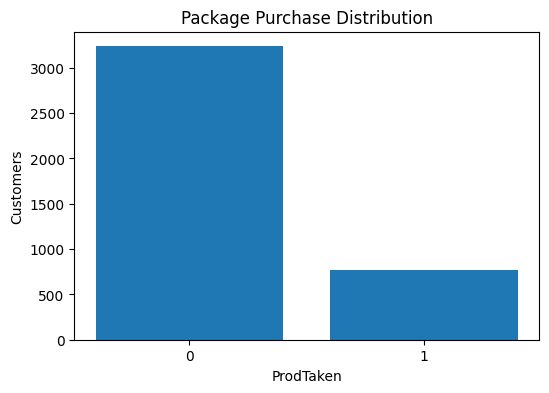

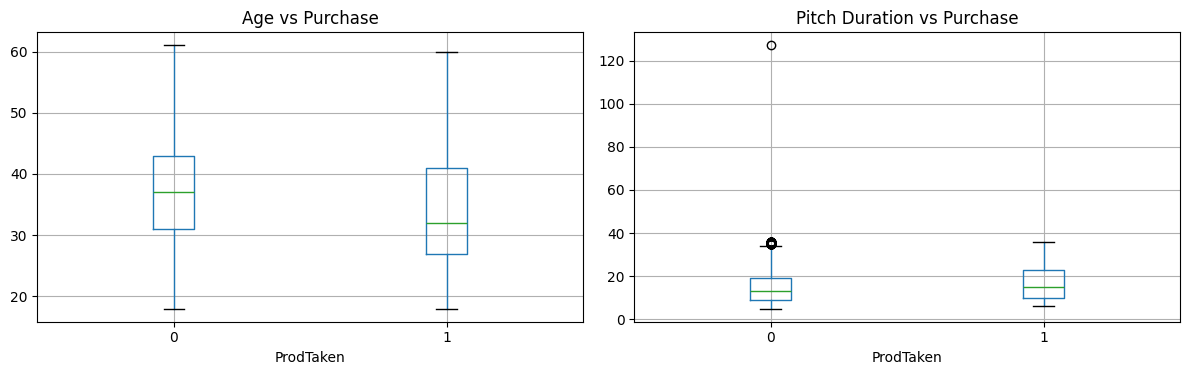


Purchase rate by TypeofContact:


,purchase_rate_%
TypeofContact,
Company Invited,22.26
Self Enquiry,18.08



Purchase rate by ProductPitched:


,purchase_rate_%
ProductPitched,
Basic,30.06
Standard,16.22
Deluxe,11.57
King,8.91
Super Deluxe,6.30



Purchase rate by MaritalStatus:


,purchase_rate_%
MaritalStatus,
Single,37.15
Unmarried,24.73
Married,14.06
Divorced,13.31



Purchase rate by Passport:


,purchase_rate_%
Passport,
1,35.93
0,12.36


In [6]:
import matplotlib.pyplot as plt

# Target balance
counts = df["ProdTaken"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Package Purchase Distribution")
plt.xlabel("ProdTaken")
plt.ylabel("Customers")
plt.show()

# Selected numeric relationships
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df.boxplot(column="Age", by="ProdTaken", ax=axes[0])
axes[0].set_title("Age vs Purchase"); axes[0].set_xlabel("ProdTaken")
df.boxplot(column="DurationOfPitch", by="ProdTaken", ax=axes[1])
axes[1].set_title("Pitch Duration vs Purchase"); axes[1].set_xlabel("ProdTaken")
plt.suptitle("")
plt.tight_layout()
plt.show()

for col in ["TypeofContact","ProductPitched","MaritalStatus","Passport"]:
    print(f"\nPurchase rate by {col}:")
    display((df.groupby(col)["ProdTaken"].mean().sort_values(ascending=False)*100).round(2).to_frame("purchase_rate_%"))

In [7]:
# Train/test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["ProdTaken"])
y = df["ProdTaken"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df["ProdTaken"] = y_train.values
test_df = X_test.copy()
test_df["ProdTaken"] = y_test.values

train_df.to_csv(DATA_DIR / "train.csv", index=False)
test_df.to_csv(DATA_DIR / "test.csv", index=False)

print(f"Training set: {train_df.shape}")
print(f"Testing set:  {test_df.shape}")
print(f"Training purchase rate: {y_train.mean():.2%}")
print(f"Testing purchase rate:  {y_test.mean():.2%}")

Training set: (3208, 19)
Testing set:  (803, 19)
Training purchase rate: 19.30%
Testing purchase rate:  19.30%


### Hugging Face train/test registration

`data_prep.py` loads the dataset directly from the Hugging Face Dataset Hub when `HF_DATASET_REPO` and `HF_TOKEN` are configured. It cleans the data, creates stratified train/test sets, saves them locally, and uploads both CSV files back to the same dataset repository.

In [8]:
# The same end-to-end preparation is available as an executable CI script.
print("Prepared files:")
print("-", DATA_DIR / "train.csv")
print("-", DATA_DIR / "test.csv")
print("CI script:", MODEL_DIR / "data_prep.py")

Prepared files:
- data/train.csv
- data/test.csv
CI script: model_building/data_prep.py


## 5. Model Building and Experimentation Tracking

Algorithms selected from the permitted list:
1. Random Forest
2. Gradient Boosting
3. XGBoost

Each model is wrapped in a single `Pipeline` containing imputation and one-hot encoding. `RandomizedSearchCV` performs hyperparameter tuning using 3-fold cross-validation and ROC-AUC as the optimization metric.

MLflow logging is included in `train.py`. The notebook environment may not have MLflow installed, so the executed notebook records an equivalent local experiment table; the GitHub workflow installs MLflow and logs parameters/metrics to `mlruns`.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

model_configs = {
    "Random Forest": (
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        {
            "model__n_estimators": [200, 300],
            "model__max_depth": [None, 8, 12, 16],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [100, 150, 200],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__max_depth": [2, 3, 4],
            "model__min_samples_leaf": [1, 2, 4]
        }
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, eval_metric="logloss", tree_method="hist", n_jobs=2),
        {
            "model__n_estimators": [150, 250, 350],
            "model__max_depth": [2, 3, 4, 5],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    )
}

print("Categorical features:", categorical_cols)
print("Numerical features:", numeric_cols)

Categorical features: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']
Numerical features: ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']


In [10]:
# Hyperparameter tuning and evaluation
results = []
best_estimators = {}

for name, (estimator, param_dist) in model_configs.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    search = RandomizedSearchCV(
        pipe, param_distributions=param_dist, n_iter=8, cv=3,
        scoring="roc_auc", random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    pred = search.predict(X_test)
    proba = search.predict_proba(X_test)[:, 1]

    row = {
        "Model": name,
        "CV ROC-AUC": search.best_score_,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, proba),
        "Best Parameters": str(search.best_params_)
    }
    results.append(row)
    best_estimators[name] = search.best_estimator_

comparison = pd.DataFrame(results).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
display(comparison[["Model","CV ROC-AUC","Accuracy","Precision","Recall","F1","Test ROC-AUC"]].round(4))

best_name = comparison.iloc[0]["Model"]
best_pipeline = best_estimators[best_name]
joblib.dump(best_pipeline, MODEL_DIR / "best_model.joblib")
comparison.to_csv(MODEL_DIR / "model_comparison.csv", index=False)

print(f"\nBest model by Test ROC-AUC: {best_name}")
print("Saved:", MODEL_DIR / "best_model.joblib")

,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,Test ROC-AUC
0,Random Forest,0.9386,0.8991,0.9405,0.5097,0.6611,0.9681
1,XGBoost,0.9043,0.8892,0.8367,0.5290,0.6482,0.8970
2,Gradient Boosting,0.8767,0.8705,0.7931,0.4452,0.5702,0.8626



Best model by Test ROC-AUC: Random Forest
Saved: model_building/best_model.joblib


              precision    recall  f1-score   support

           0     0.8943    0.9923    0.9407       648
           1     0.9405    0.5097    0.6611       155

    accuracy                         0.8991       803
   macro avg     0.9174    0.7510    0.8009       803
weighted avg     0.9032    0.8991    0.8868       803

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,643,5
Actual 1,76,79


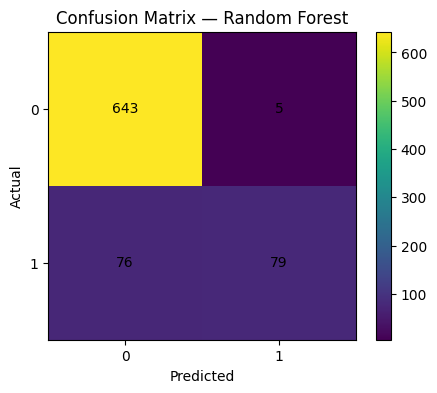

In [11]:
# Detailed evaluation of the selected model
best_pred = best_pipeline.predict(X_test)
best_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_pred, digits=4))
cm = confusion_matrix(y_test, best_pred)
print("Confusion matrix:")
display(pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Predicted 0","Predicted 1"]))

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1]); plt.yticks([0,1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.colorbar()
plt.show()

### Experiment tracking

The production training script contains MLflow integration. It logs:
- model name/run name,
- every tuned hyperparameter returned by `RandomizedSearchCV`,
- CV ROC-AUC,
- test accuracy,
- precision,
- recall,
- F1,
- test ROC-AUC.

If MLflow is unavailable in the current notebook runtime, the same experiment results are persisted in `model_comparison.csv` so the notebook remains executable without errors.

In [12]:
# Inspect persisted experiment results
display(pd.read_csv(MODEL_DIR / "model_comparison.csv")[["Model","CV ROC-AUC","Accuracy","Precision","Recall","F1","Test ROC-AUC"]].round(4))
print("Experiment artifact:", MODEL_DIR / "model_comparison.csv")
print("MLflow implementation:", MODEL_DIR / "train.py")

,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,Test ROC-AUC
0,Random Forest,0.9386,0.8991,0.9405,0.5097,0.6611,0.9681
1,XGBoost,0.9043,0.8892,0.8367,0.5290,0.6482,0.8970
2,Gradient Boosting,0.8767,0.8705,0.7931,0.4452,0.5702,0.8626


Experiment artifact: model_building/model_comparison.csv
MLflow implementation: model_building/train.py


## 6. Model Registration — Hugging Face Model Hub

The production script registers the selected `best_model.joblib` and the experiment comparison file to the configured Hugging Face Model repository. The app downloads this model at runtime, avoiding hard-coding a model into the frontend.

In [13]:
# Optional model registration:
# os.environ["HF_TOKEN"] = "YOUR_TOKEN"
# os.environ["HF_MODEL_REPO"] = "YOUR_USERNAME/tourism-purchase-model"
# !python tourism_project/model_building/train.py

print("Model artifact ready for Hugging Face registration:", MODEL_DIR / "best_model.joblib")
print("Registration is automated in the GitHub Actions pipeline.")

Model artifact ready for Hugging Face registration: model_building/best_model.joblib
Registration is automated in the GitHub Actions pipeline.


## 7. Deployment — Streamlit + Docker

The frontend accepts the same business features used during training, creates a one-row DataFrame, loads the registered model from Hugging Face, and displays purchase probability plus a simple targeting recommendation.

Files created:
- `deployment/app.py`
- `deployment/requirements.txt`
- `deployment/Dockerfile`
- `deployment/hosting.py`

In [14]:
# Show deployment files and their key configuration
for file in ["app.py","requirements.txt","Dockerfile","hosting.py"]:
    p=DEPLOY_DIR/file
    print(f"\n--- {p} ---")
    print(p.read_text()[:1800])


--- deployment/app.py ---

import os, joblib, pandas as pd, streamlit as st
from huggingface_hub import hf_hub_download

st.set_page_config(page_title="Wellness Tourism Purchase Predictor", page_icon="✈️", layout="centered")
st.title("✈️ Wellness Tourism Package Predictor")
st.write("Predict whether a customer is likely to purchase the package before contacting them.")

MODEL_REPO=os.getenv("HF_MODEL_REPO","")
MODEL_FILE=os.getenv("MODEL_FILE","../model_building/best_model.joblib")
if MODEL_REPO:
    model_path=hf_hub_download(repo_id=MODEL_REPO, filename="best_model.joblib", repo_type="model")
else:
    model_path=MODEL_FILE
model=joblib.load(model_path)

c1,c2=st.columns(2)
with c1:
    age=st.number_input("Age",18,100,35)
    contact=st.selectbox("Type of Contact",["Company Invited","Self Inquiry"])
    city=st.selectbox("City Tier",[1,2,3])
    occupation=st.selectbox("Occupation",["Salaried","Small Business","Large Business","Free Lancer"])
    gender=st.selectbox("Gender",["Male

## 8. GitHub Actions MLOps Pipeline

The workflow has four dependent jobs:

**Register dataset → Prepare data → Train/tune/evaluate/register model → Deploy Streamlit Space**

The pipeline runs on every push to `main` and can also be started manually using `workflow_dispatch`. GitHub Secrets required:
- `HF_TOKEN`
- `HF_DATASET_REPO`
- `HF_MODEL_REPO`
- `HF_SPACE_REPO`

In [15]:
workflow_path = MASTER_DIR / ".github/workflows/pipeline.yml"
print(workflow_path.read_text())

name: Tourism Project Pipeline

on:
  push:
    branches: [main]
  workflow_dispatch:

jobs:
  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Install dependencies
        run: pip install -r deployment/requirements.txt
      - name: Register dataset on Hugging Face
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          HF_DATASET_REPO: ${{ secrets.HF_DATASET_REPO }}
        run: python model_building/register_dataset.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Install dependencies
        run: pip install -r deployment/requirements.txt
      - name: Prepare train and test data
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
          HF_DATASET_REPO: ${{ secrets.HF_DATASET_REPO }}
        run: python model_building/data_prep.py
      - uses: actions/upload-artifact@v4
        with:
          name: prepared-data
          pa

## 9. Final Project Structure

In [16]:
# Display the final repository structure
for p in sorted(MASTER_DIR.rglob("*")):
    if p.is_file():
        print(p.relative_to(MASTER_DIR))

.github/workflows/pipeline.yml
README.md
Tourism_MLOps_Assignment.html
Tourism_MLOps_Assignment.ipynb
data/test.csv
data/tourism.csv
data/train.csv
deployment/Dockerfile
deployment/app.py
deployment/hosting.py
deployment/requirements.txt
model_building/__init__.py
model_building/best_model.joblib
model_building/data_prep.py
model_building/model_comparison.csv
model_building/register_dataset.py
model_building/train.py
tourism_project/data/test.csv
tourism_project/data/tourism.csv
tourism_project/data/train.csv
tourism_project/model_building/best_model.joblib
tourism_project/model_building/model_comparison.csv


## 10. Hosting Configuration

After creating the public Hugging Face Space, set:

```text
HF_SPACE_REPO=username/tourism-wellness-predictor
HF_MODEL_REPO=username/tourism-purchase-model
HF_DATASET_REPO=username/tourism-dataset
```

`deployment/hosting.py` pushes the complete Docker/Streamlit frontend folder to the Space. The Space then loads the model from the Hugging Face Model Hub.

### Required evidence for final submission
1. Public GitHub repository URL.
2. Screenshot of GitHub folder structure.
3. Screenshot of successful GitHub Actions workflow.
4. Public Hugging Face Space URL.
5. Screenshot of the running Streamlit prediction page.
6. These URLs should also be pasted into this notebook before the final HTML export.

In [17]:
# Fill these only after you create your public repositories/spaces.
GITHUB_REPO_URL = "PASTE_PUBLIC_GITHUB_REPOSITORY_URL_HERE"
HF_SPACE_URL = "PASTE_PUBLIC_HUGGING_FACE_SPACE_URL_HERE"

print("GitHub repository:", GITHUB_REPO_URL)
print("Hugging Face Space:", HF_SPACE_URL)

GitHub repository: PASTE_PUBLIC_GITHUB_REPOSITORY_URL_HERE
Hugging Face Space: PASTE_PUBLIC_HUGGING_FACE_SPACE_URL_HERE


## 11. Business Insights and Conclusion

### Key insights
- The target variable is imbalanced, so model evaluation should consider ROC-AUC, precision, recall and F1 rather than accuracy alone.
- Customer profile, product-pitch and sales-interaction variables provide predictive signal.
- Removing identifier/export columns prevents irrelevant information from entering the model.
- A single preprocessing + model pipeline makes training and inference consistent.
- Cross-validation and hyperparameter tuning improve reliability compared with a single default model.
- The selected model can be registered centrally and consumed by a lightweight Streamlit frontend.
- GitHub Actions provides repeatability: new code pushed to `main` can automatically refresh the dataset registration, preparation, model training and deployment.

### Final recommendation
Use the model as a **lead-prioritization tool**, not as an automatic rejection mechanism. Sales teams should prioritize high-probability customers while retaining a broader outreach strategy for borderline cases. Monitor production performance over time and retrain when customer behavior or campaign mix changes.

### Submission readiness
This notebook contains the executed analytical/modeling work, while the accompanying project folder contains the deployment and CI/CD assets required by the rubric.